Link to the Dataset

In [ ]:
https://www.kaggle.com/datasets/shanmukh05/traffic-sign-cropped

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# CNN Image Classification Full Pipeline Notebook

# This notebook covers:
# 1. Data Loading & Validation
# 2. Exploratory Data Analysis (EDA)
# 3. Dataset Preparation & Augmentation
# 4. Two CNN Models (Simple CNN + Transfer Learning CNN)
# 5. Training, Evaluation, and Reporting

# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.model_selection import train_test_split

IMAGE_DIR = "/content/drive/MyDrive/test_data/test_data"


In [3]:
# Load CSV labels
df = pd.read_csv("test_labels.csv")
df.head()

,image,label
0,00000.jpg,16
1,00001.jpg,1
2,00002.jpg,38
3,00003.jpg,33
4,00004.jpg,11


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12630 entries, 0 to 12629
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   12630 non-null  object
 1   label   12630 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 197.5+ KB
Missing values per column:
 image    0
label    0
dtype: int64
Rows: 12630
Columns: ['image', 'label']


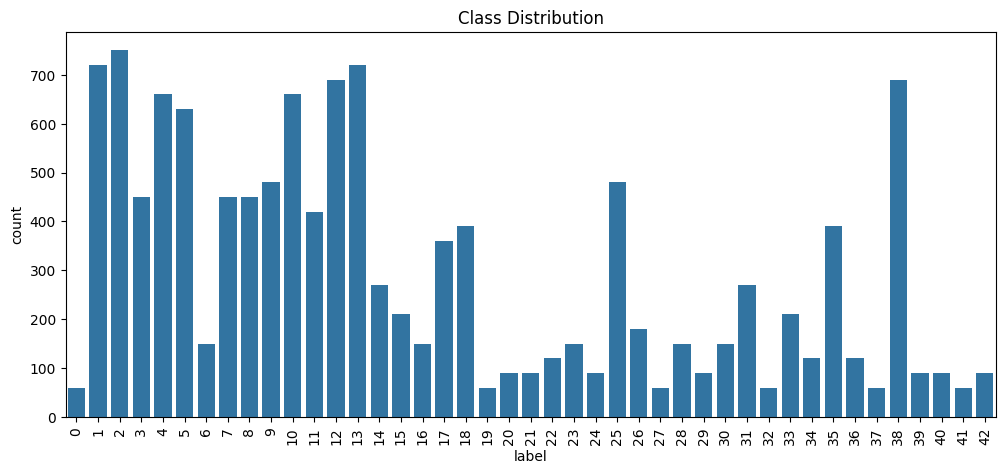

In [4]:
# =============================
# Exploratory Data Analysis (EDA)
# =============================

# Basic info
df.info()

# Summary statistics
df.describe()

# Check missing values
print("Missing values per column:\n", df.isna().sum())
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

# Class distribution plot
plt.figure(figsize=(12,5))
sns.countplot(x=df['label'])
plt.title("Class Distribution")
plt.xticks(rotation=90)
plt.show()

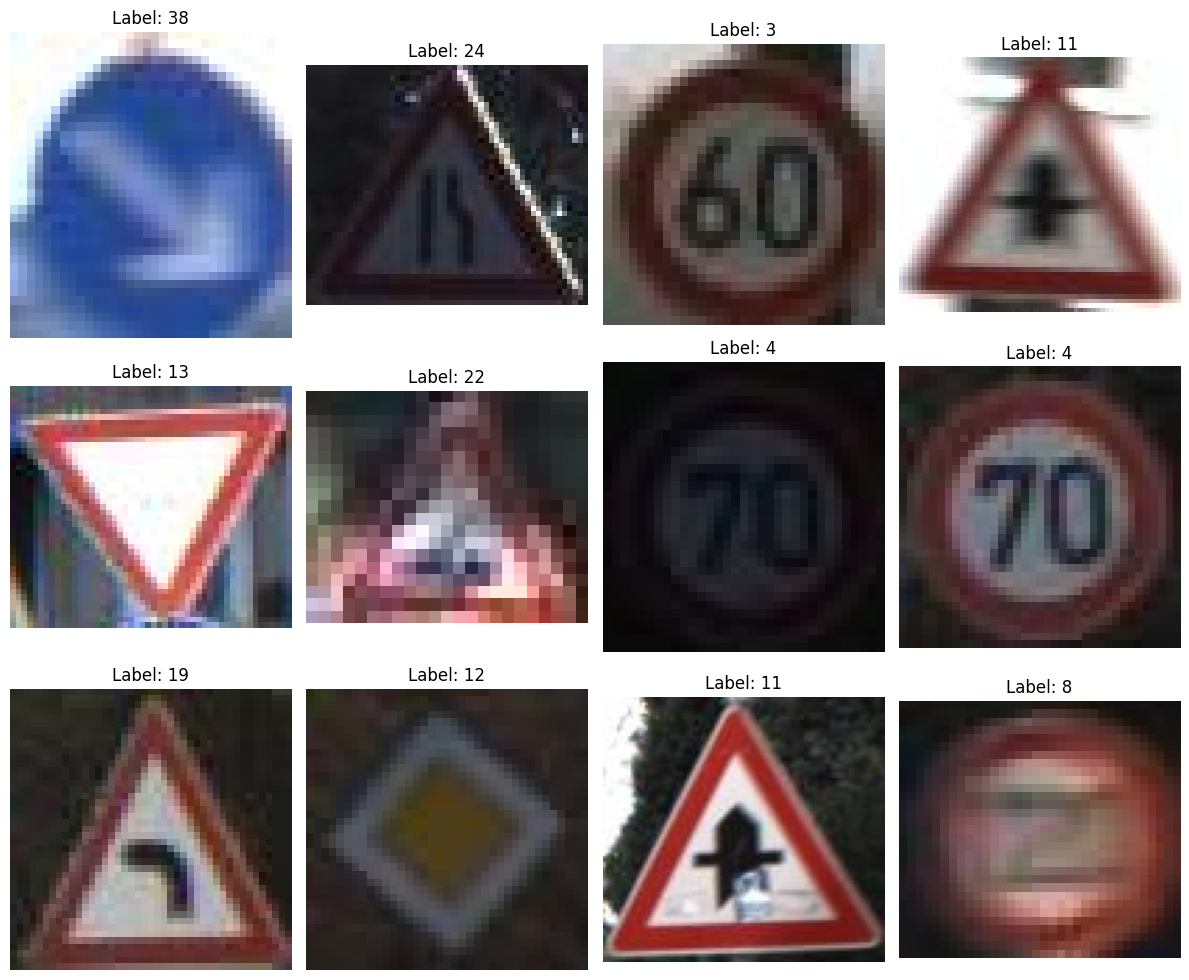

In [5]:
import random
import matplotlib.image as mpimg

# Select 12 random samples from the DataFrame
sample = df.sample(12)

# Create a figure to display the images
plt.figure(figsize=(12,10))
# Loop through each sampled image and its label
for i, (img, label) in enumerate(zip(sample["image"], sample["label"])):
    # Create a subplot for each image (3 rows, 4 columns)
    plt.subplot(3,4,i+1)
    # Construct the full image path
    image_path = os.path.join(IMAGE_DIR, img)
    # Read the image using matplotlib
    image = mpimg.imread(image_path)
    # Display the image
    plt.imshow(image)
    # Set the title of the subplot to the image's label
    plt.title(f"Label: {label}")
    # Turn off the axis for a cleaner look
    plt.axis("off")
# Adjust subplot parameters for a tight layout
plt.tight_layout()
# Display the plot
plt.show()

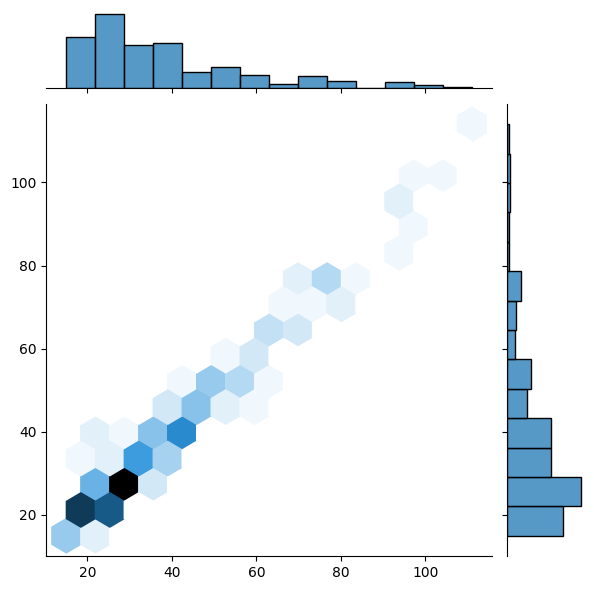

In [6]:
from PIL import Image

widths = []
heights = []

# Loop through a sample of 200 image filenames from the DataFrame to speed up processing
for img in df["image"].sample(200):
    # Construct the full path to the image file
    path = os.path.join(IMAGE_DIR, img)
    # Open the image using PIL (Pillow)
    image = Image.open(path)
    # Get the width and height of the image
    w, h = image.size
    # Append the width and height to their respective lists
    widths.append(w)
    heights.append(h)

# Create a joint plot using seaborn to visualize the distribution of widths and heights
# 'hex' kind creates a hexagonal binning plot, useful for dense scatter plots
sns.jointplot(x=widths, y=heights, kind='hex')
# Display the plot
plt.show()

In [7]:
# =============================
# Train/Validation/Test Split
# =============================
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(len(train_df), len(val_df), len(test_df))

8841 1894 1895


In [8]:
# =============================
# Dataset Preparation
# =============================
image_path = "/content/drive/MyDrive/test_data/test_data"  # specify your folder containing JPGs

# Convert 'label' column to string type for categorical classification
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)

# ImageDataGenerator
train_gen = ImageDataGenerator(rescale=1/255., rotation_range=20, width_shift_range=0.1,
                               height_shift_range=0.1, horizontal_flip=True)
val_gen = ImageDataGenerator(rescale=1/255.)

test_gen = ImageDataGenerator(rescale=1/255.)

train_data = train_gen.flow_from_dataframe(train_df, directory=image_path, x_col='image', y_col='label',
                                           target_size=(224,224), class_mode='categorical', batch_size=32)
val_data = val_gen.flow_from_dataframe(val_df, directory=image_path, x_col='image', y_col='label',
                                       target_size=(224,224), class_mode='categorical', batch_size=32)
test_data = test_gen.flow_from_dataframe(test_df, directory=image_path, x_col='image', y_col='label',
                                         target_size=(224,224), class_mode='categorical', batch_size=32)

Found 8841 validated image filenames belonging to 43 classes.
Found 1894 validated image filenames belonging to 43 classes.
Found 1895 validated image filenames belonging to 43 classes.


In [9]:
# =============================
# Model 1: Simple CNN
# =============================
model1 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(df['label'].nunique(), activation='softmax')
])

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model1.summary()

history1 = model1.fit(train_data, validation_data=val_data, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,174,507 (42.63 MB)

 Trainable params: 11,174,507 (42.63 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 3928s 14s/step - accuracy: 0.1858 - loss: 3.1793 - val_accuracy: 0.4203 - val_loss: 1.8540
Epoch 2/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 1173s 4s/step - accuracy: 0.3458 - loss: 2.1228 - val_accuracy: 0.5544 - val_loss: 1.3525
Epoch 3/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 1166s 4s/step - accuracy: 0.4484 - loss: 1.7263 - val_accuracy: 0.6737 - val_loss: 1.0153
Epoch 4/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 1172s 4s/step - accuracy: 0.5244 - loss: 1.4397 - val_accuracy: 0.7027 - val_loss: 0.8503
Epoch 5/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 1183s 4s/step - accuracy: 0.5834 - loss: 1.2503 - val_accuracy: 0.8073 - val_loss: 0.6191


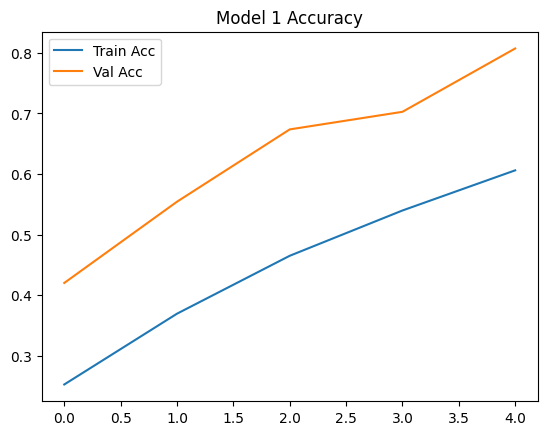

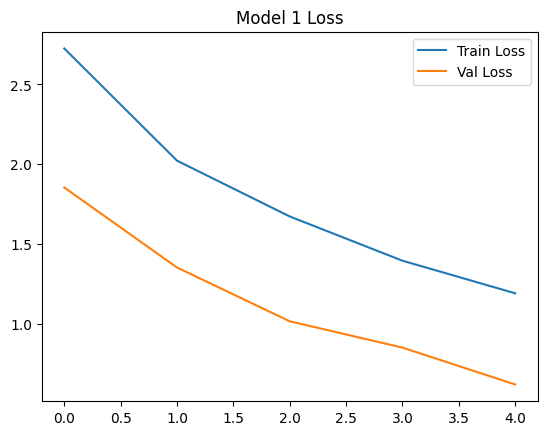

In [10]:
# =============================
# Model 1: Performance Plots
# =============================
plt.plot(history1.history['accuracy'], label='Train Acc')
plt.plot(history1.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('Model 1 Accuracy'); plt.show()

plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Model 1 Loss'); plt.show()

In [11]:
# =============================
# Model 2: Transfer Learning (EfficientNetB0)
# =============================
from tensorflow.keras.optimizers import Adam
base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224,224,3), pooling='avg')
base.trainable = False

model2 = Sequential([
    base,
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(df['label'].nunique(), activation='softmax')
])

model2.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model2.summary()

history2 = model2.fit(train_data, validation_data=val_data, epochs=5)

# Unfreeze top layers for fine-tuning
print("\nPhase 2: Fine-tuning with unfrozen layers...")
base.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = len(base.layers) - 30
for layer in base.layers[:fine_tune_at]:
    layer.trainable = False

# Even lower learning rate for fine-tuning
model2.compile(optimizer=Adam(learning_rate=1e-5),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

# Continue training
history2_phase2 = model2.fit(train_data, validation_data=val_data, epochs=5)

print("Training completed!")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,388,558 (16.74 MB)

 Trainable params: 338,987 (1.29 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 942s 3s/step - accuracy: 0.0420 - loss: 3.6385 - val_accuracy: 0.0570 - val_loss: 3.4905
Epoch 2/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 948s 3s/step - accuracy: 0.0544 - loss: 3.5332 - val_accuracy: 0.0570 - val_loss: 3.4844
Epoch 3/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 994s 3s/step - accuracy: 0.0519 - loss: 3.5457 - val_accuracy: 0.0570 - val_loss: 3.4729
Epoch 4/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 934s 3s/step - accuracy: 0.0530 - loss: 3.5156 - val_accuracy: 0.0523 - val_loss: 3.4716
Epoch 5/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 970s 3s/step - accuracy: 0.0509 - loss: 3.5177 - val_accuracy: 0.0544 - val_loss: 3.4689

Phase 2: Fine-tuning with unfrozen layers...
Epoch 1/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 1089s 4s/step - accuracy: 0.0409 - loss: 3.6616 - val_accuracy: 0.0591 - val_loss: 3.4728
Epoch 2/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 1065s 4s/step - accuracy: 0.0554 - loss: 3.5536 - val_accuracy: 0.0591 - val_loss: 3.4704
Epoch 3/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 1068s 4s/step - a

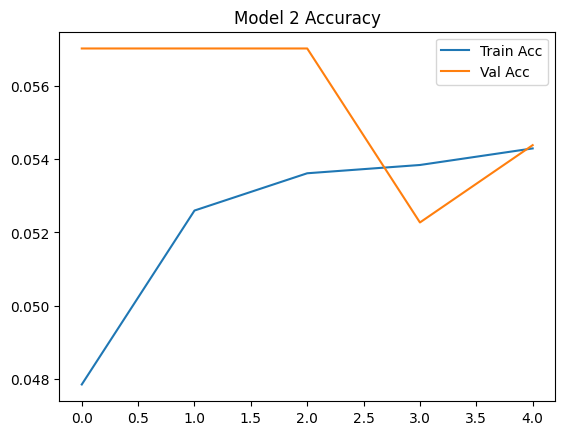

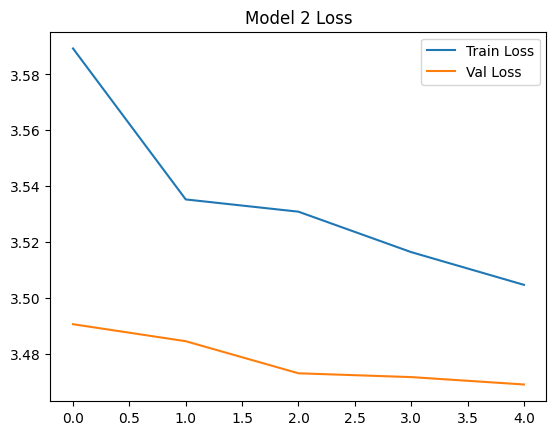

In [12]:
# =============================
# Model 2 Performance Plots
# =============================
plt.plot(history2.history['accuracy'], label='Train Acc')
plt.plot(history2.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('Model 2 Accuracy'); plt.show()

plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Model 2 Loss'); plt.show()

In [13]:
# =============================
# Final Evaluation on Test Set
# =============================
print("Model 1 Test Accuracy:", model1.evaluate(test_data))
print("Model 2 Test Accuracy:", model2.evaluate(test_data))


60/60 ━━━━━━━━━━━━━━━━━━━━ 656s 11s/step - accuracy: 0.8040 - loss: 0.6055
Model 1 Test Accuracy: [0.62525475025177, 0.8021107912063599]
60/60 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.0605 - loss: 3.4442
Model 2 Test Accuracy: [3.458015203475952, 0.059630606323480606]


In [14]:
# =============================
# Confusion Matrices
# =============================
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predictions
pred1 = np.argmax(model1.predict(test_data), axis=1)
pred2 = np.argmax(model2.predict(test_data), axis=1)
true = test_data.classes
labels = list(test_data.class_indices.keys())



60/60 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step


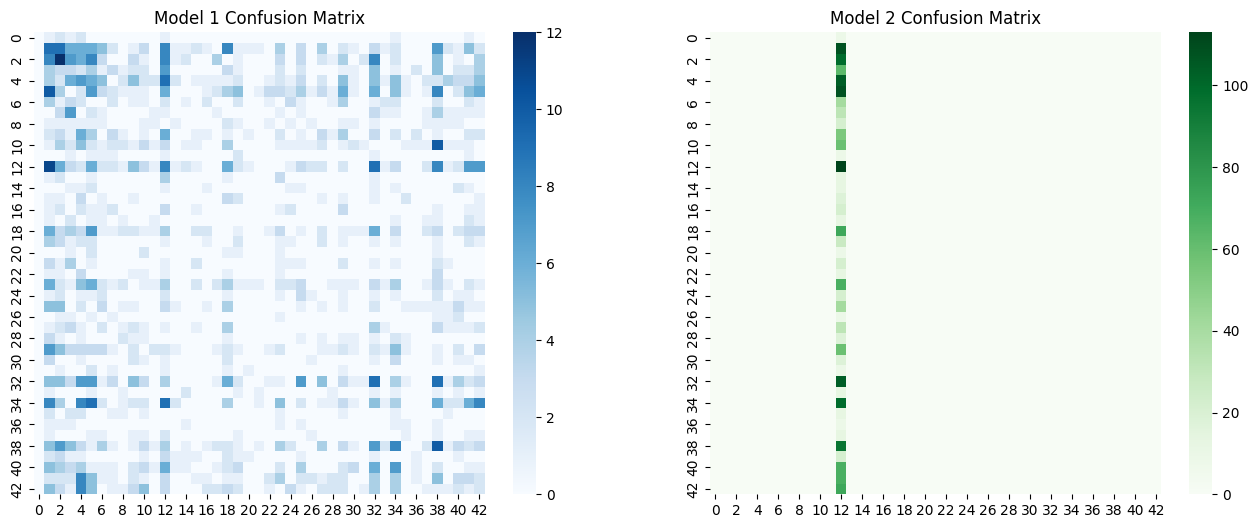

In [15]:
# Confusion matrix plots
fig, ax = plt.subplots(1,2, figsize=(16,6))
sns.heatmap(confusion_matrix(true, pred1), annot=False, cmap='Blues', ax=ax[0])
ax[0].set_title('Model 1 Confusion Matrix')

sns.heatmap(confusion_matrix(true, pred2), annot=False, cmap='Greens', ax=ax[1])
ax[1].set_title('Model 2 Confusion Matrix')
plt.show()

In [16]:
# =============================
# Model Comparison Table
# =============================
model_comparison = pd.DataFrame({
    'Model': ['Simple CNN', 'EfficientNetB0'],
    'Train Accuracy': [history1.history['accuracy'][-1], history2.history['accuracy'][-1]],
    'Validation Accuracy': [history1.history['val_accuracy'][-1], history2.history['val_accuracy'][-1]],
    'Test Accuracy': [model1.evaluate(test_data)[1], model2.evaluate(test_data)[1]]
})

print(model_comparison)

60/60 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.8147 - loss: 0.6127
60/60 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.0545 - loss: 3.4666
            Model  Train Accuracy  Validation Accuracy  Test Accuracy
0      Simple CNN        0.606153             0.807286       0.802111
1  EfficientNetB0        0.054293             0.054382       0.059631


In [17]:
# =============================
# Hyperparameter Tuning (Simple CNN)
# =============================
!pip install keras-tuner
from keras_tuner import RandomSearch

def build_model(hp):
    model = Sequential()
    model.add(Conv2D(hp.Int('filters1', 32, 128, step=32), (3,3), activation='relu', input_shape=(224,224,3)))
    model.add(MaxPooling2D(2,2))
    model.add(Conv2D(hp.Int('filters2', 32, 256, step=32), (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))
    model.add(Flatten())
    model.add(Dense(hp.Int('dense_units', 64, 256, step=64), activation='relu'))
    model.add(Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))
    model.add(Dense(df['label'].nunique(), activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.3 MB/s eta 0:00:00


In [ ]:
 tuner = RandomSearch(
     build_model,
     objective='val_accuracy',
     max_trials=2,
     directory='tuner_dir',
     project_name='cnn_tuning'
 )

 tuner.search(train_data, epochs=5, validation_data=val_data)
 best_model = tuner.get_best_models(num_models=1)[0]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
64                |64                |filters1
256               |256               |filters2
256               |256               |dense_units
0.4               |0.4               |dropout

Epoch 1/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 4109s 15s/step - accuracy: 0.2010 - loss: 4.1182 - val_accuracy: 0.4520 - val_loss: 1.7092
Epoch 2/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 4123s 15s/step - accuracy: 0.3763 - loss: 1.9879 - val_accuracy: 0.5253 - val_loss: 1.4566
Epoch 3/5
277/277 ━━━━━━━━━━━━━━━━━━━━ 4130s 15s/step - accuracy: 0.4470 - loss: 1.7287 - val_accuracy: 0.6315 - val_loss: 1.2221
Epoch 4/5
121/277 ━━━━━━━━━━━━━━━━━━━━ 37:17 14s/step - accuracy: 0.5058 - loss: 1.5461

In [ ]:
# =============================
# Grad-CAM Visualization
# =============================
import cv2
from tensorflow.keras import Model
import numpy as np # Ensure numpy is imported
import tensorflow as tf # Ensure tensorflow is imported

# Ensure model1 is built before trying to access its input/output tensors for the functional API
# This addresses the 'AttributeError: The layer sequential has never been called and thus has no defined input.'
if not model1.built:
    model1.build(input_shape=(None, 224, 224, 3))

# Choose model1 for Grad-CAM
# Corrected: model1.layers[4] is the last Conv2D layer in model1
grad_model = Model(inputs=model1.layers[0].input, outputs=[model1.layers[-1].output, model1.layers[4].output])

# Function to compute Grad-CAM heatmap
def make_gradcam_heatmap(img_array, grad_model):
    with tf.GradientTape() as tape:
        preds, conv_output = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_score = preds[:, pred_index]

    # Compute gradients of the class score with respect to the feature map of the last conv layer
    grads = tape.gradient(class_score, conv_output)

    # Global average pooling of the gradients to get importance weights for each feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=[0, 1, 2])

    # Multiply each channel in the feature map by its importance weight
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU to the heatmap and normalize
    heatmap = tf.maximum(heatmap, 0)
    if tf.reduce_max(heatmap) == 0:
        heatmap = heatmap
    else:
        heatmap = heatmap / tf.reduce_max(heatmap)
    return heatmap.numpy() # Convert to numpy for matplotlib and opencv

In [ ]:
# Select one test sample for Grad-CAM
sample_path = os.path.join(image_path, test_df.iloc[0]['image'])
img = tf.keras.preprocessing.image.load_img(sample_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

heatmap = make_gradcam_heatmap(img_array, grad_model)

plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.show()

In [ ]:
# =============================
# Grad-CAM Overlay on Original Image
# =============================

def overlay_gradcam(original_img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(original_img, 1 - alpha, heatmap, alpha, 0)
    return overlay

orig = cv2.imread(sample_path)
orig_resized = cv2.resize(orig, (224,224))
overlay_img = overlay_gradcam(orig_resized, heatmap)
plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Overlay")
plt.show()

In [ ]:
# =============================
# Multiple-Sample Grad-CAM Batch Visualisations
# =============================
sample_batch = test_df.sample(5)
plt.figure(figsize=(15,8))
for i, row in enumerate(sample_batch.itertuples()):
    img_path = os.path.join(image_path, row.image)
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    arr = tf.keras.preprocessing.image.img_to_array(img)
    arr = np.expand_dims(arr, 0) / 255.0
    heat = make_gradcam_heatmap(arr, grad_model)
    overlay = overlay_gradcam(cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR), heat)
    plt.subplot(2,5,i+1)
    plt.imshow(img); plt.title("Original")
    plt.subplot(2,5,i+6)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); plt.title("Grad-CAM")
plt.show()

In [ ]:
# =============================
# SHAP Feature Importance for CNN Embeddings
# =============================
#import shap
#from tensorflow.keras import Model # Import Model if not already

# Extract embeddings from EfficientNet
#embedding_model = Model(inputs=model1.layers[0].input, outputs=model1.layers[-3].output)

# Use a small background set
#background = next(train_data)[0][:20]
#explainer = shap.DeepExplainer(embedding_model, background)
#test_images = next(test_data)[0][:5]
#shap_values = explainer.shap_values(test_images)

#shap.image_plot(shap_values, test_images)